# Monte Carlo Methods for Simulation & Numerical Methods

This notebook covers the foundations of Monte Carlo (MC) simulation:

1. **Estimating π** — geometric probability
2. **Numerical Integration** — 1D and 2D
3. **Option Pricing** — risk-neutral valuation of a European call
4. **Variance Reduction** — antithetic variates
5. **Convergence Analysis** — empirical verification of the $O(N^{-1/2})$ rate

Monte Carlo is unique because its convergence rate is **dimension-independent**, making it indispensable for high-dimensional problems.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from math import log, sqrt, exp, erf

# Reproducibility and style
np.random.seed(42)
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11


## 1. Estimating π with Monte Carlo

Sample points uniformly in the unit square $[0,1] \times [0,1]$ and count the fraction that falls inside the quarter circle $x^2 + y^2 \leq 1$.

Since:
$$\text{Area}_{\text{quarter circle}} = \frac{\pi}{4}, \quad \text{Area}_{\text{square}} = 1$$

We have:
$$\pi \approx 4 \times \frac{N_{\text{inside}}}{N_{\text{total}}}$$

This is a geometric Monte Carlo estimator.


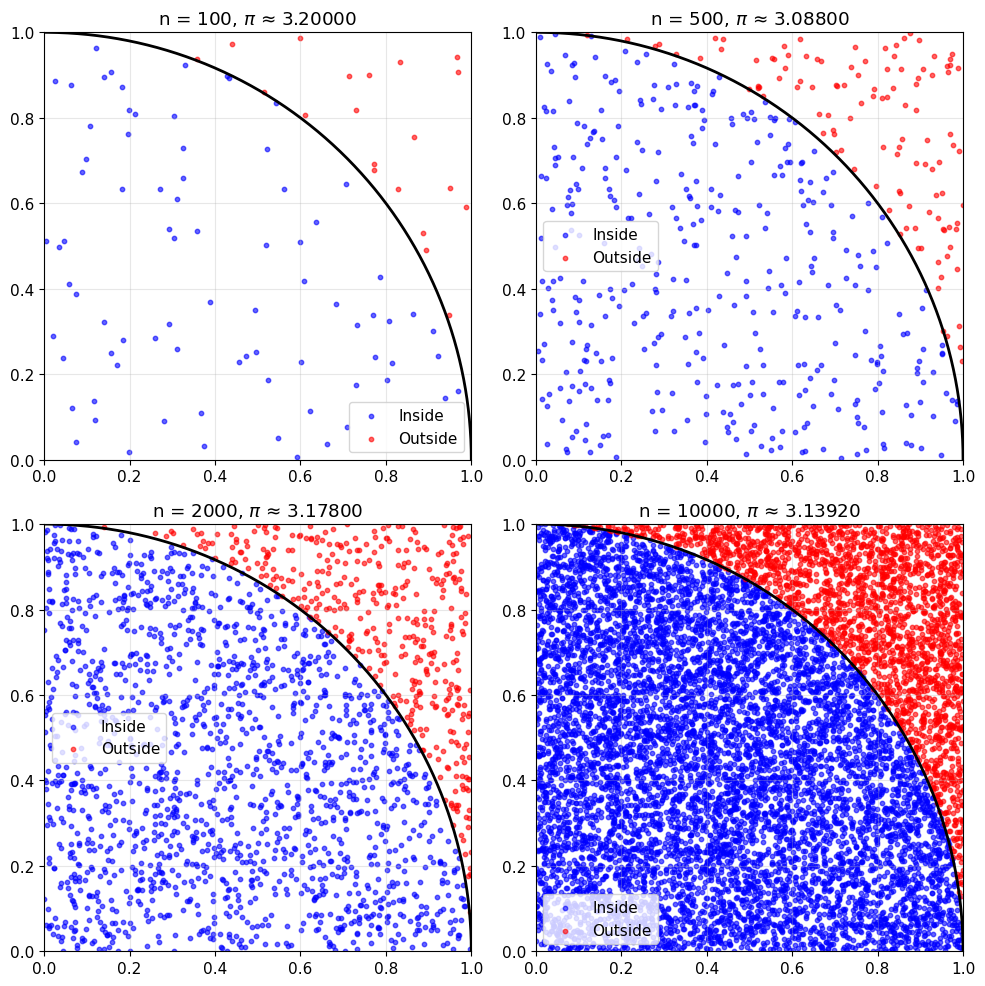

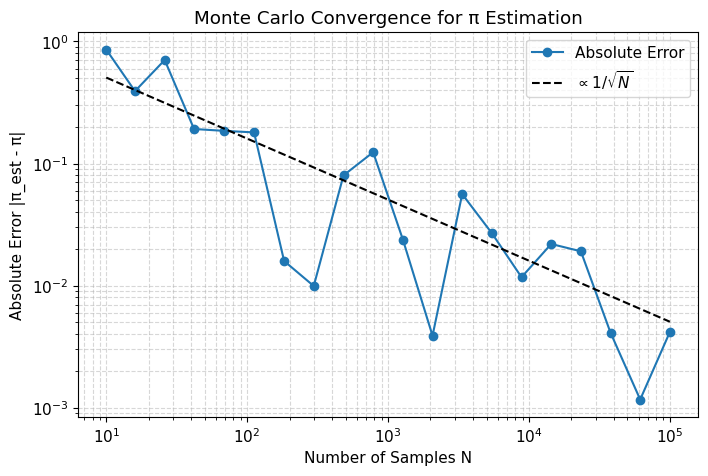

In [2]:
def estimate_pi(n):
    x = np.random.rand(n)
    y = np.random.rand(n)
    inside = (x**2 + y**2) <= 1
    pi_est = 4.0 * np.sum(inside) / n
    return pi_est, x, y, inside

# Visualize for different sample sizes
sample_sizes = [100, 500, 2000, 10000]
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes = axes.flatten()

for idx, n in enumerate(sample_sizes):
    pi_est, x, y, inside = estimate_pi(n)
    ax = axes[idx]
    ax.scatter(x[inside], y[inside], c='blue', s=10, alpha=0.6, label='Inside')
    ax.scatter(x[~inside], y[~inside], c='red', s=10, alpha=0.6, label='Outside')
    theta = np.linspace(0, np.pi/2, 200)
    ax.plot(np.cos(theta), np.sin(theta), 'k-', lw=2)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect('equal')
    ax.set_title('n = {}, $\\pi$ ≈ {:.5f}'.format(n, pi_est))
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Convergence curve
N_vals = np.logspace(1, 5, 20, dtype=int)
pi_estimates = [estimate_pi(n)[0] for n in N_vals]
errors = np.abs(np.array(pi_estimates) - np.pi)

plt.figure(figsize=(8, 5))
plt.loglog(N_vals, errors, 'o-', label='Absolute Error')
plt.loglog(N_vals, 1.6 / np.sqrt(N_vals), 'k--', label=r'$\propto 1 / \sqrt{N}$')
plt.xlabel('Number of Samples N')
plt.ylabel('Absolute Error |π_est - π|')
plt.title('Monte Carlo Convergence for π Estimation')
plt.legend()
plt.grid(True, which='both', ls='--', alpha=0.5)
plt.show()


## 2. Monte Carlo Integration

For a definite integral:
$$I = \int_a^b f(x) \, dx$$

The Monte Carlo estimator is:
$$\hat{I}_N = (b-a) \cdot \frac{1}{N} \sum_{i=1}^N f(X_i), \quad X_i \sim \text{Uniform}(a,b)$$

By the Strong Law of Large Numbers, $\hat{I}_N \to I$ almost surely as $N \to \infty$.

The standard error decays as:
$$\text{SE}(\hat{I}_N) = \frac{(b-a) \cdot \sigma_f}{\sqrt{N}}$$

where $\sigma_f$ is the standard deviation of $f(X)$ under the uniform measure.


1D Integral of exp(x) from 0 to 1:
Monte Carlo estimate: 1.716834
True value:           1.718282
Relative error:       0.0842%

2D Integral of x*y over [0,1]^2:
Monte Carlo estimate: 0.250422
True value:           0.250000
Relative error:       0.1688%


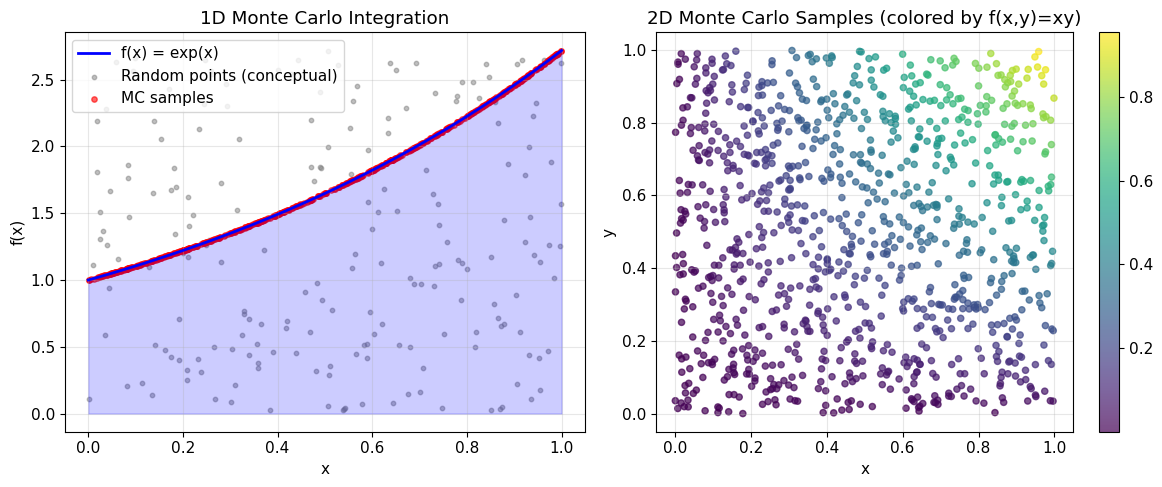

In [3]:
# 1D Integration: integral of exp(x) from 0 to 1 = e - 1
def mc_integral_1d(f, a, b, N):
    x = np.random.uniform(a, b, N)
    y = f(x)
    return (b - a) * np.mean(y), y

# 2D Integration: integral of x*y over unit square = 1/4
def mc_integral_2d(f, x_bounds, y_bounds, N):
    x = np.random.uniform(x_bounds[0], x_bounds[1], N)
    y = np.random.uniform(y_bounds[0], y_bounds[1], N)
    z = f(x, y)
    area = (x_bounds[1] - x_bounds[0]) * (y_bounds[1] - y_bounds[0])
    return area * np.mean(z), x, y, z

f1d = lambda x: np.exp(x)
true_val_1d = np.exp(1) - 1

f2d = lambda x, y: x * y
true_val_2d = 0.25

N = 100000
est_1d, samples_1d = mc_integral_1d(f1d, 0, 1, N)
est_2d, x_2d, y_2d, z_2d = mc_integral_2d(f2d, [0, 1], [0, 1], N)

print("1D Integral of exp(x) from 0 to 1:")
print("Monte Carlo estimate: {:.6f}".format(est_1d))
print("True value:           {:.6f}".format(true_val_1d))
print("Relative error:       {:.4%}".format(abs(est_1d - true_val_1d) / true_val_1d))

print("\n2D Integral of x*y over [0,1]^2:")
print("Monte Carlo estimate: {:.6f}".format(est_2d))
print("True value:           {:.6f}".format(true_val_2d))
print("Relative error:       {:.4%}".format(abs(est_2d - true_val_2d) / true_val_2d))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

x_fine = np.linspace(0, 1, 500)
axes[0].plot(x_fine, f1d(x_fine), 'b-', lw=2, label='f(x) = exp(x)')
axes[0].scatter(np.random.uniform(0, 1, 200), np.random.uniform(0, np.e, 200),
                c='gray', s=10, alpha=0.5, label='Random points (conceptual)')
x_samp = np.random.uniform(0, 1, 500)
axes[0].scatter(x_samp, f1d(x_samp), c='red', s=15, alpha=0.6, label='MC samples')
axes[0].fill_between(x_fine, 0, f1d(x_fine), alpha=0.2, color='blue')
axes[0].set_title('1D Monte Carlo Integration')
axes[0].set_xlabel('x')
axes[0].set_ylabel('f(x)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

sc = axes[1].scatter(x_2d[:1000], y_2d[:1000], c=z_2d[:1000], cmap='viridis', s=20, alpha=0.7)
axes[1].set_title('2D Monte Carlo Samples (colored by f(x,y)=xy)')
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')
plt.colorbar(sc, ax=axes[1])
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 3. Monte Carlo for Option Pricing

Under the risk-neutral measure, the price of a European call option is the discounted expected payoff:

$$C = e^{-rT} \mathbb{E}^{\mathbb{Q}}\left[ \max(S_T - K, 0) \right]$$

where the stock price follows Geometric Brownian Motion:
$$S_T = S_0 \exp\left(\left(r - \frac{\sigma^2}{2}\right)T + \sigma\sqrt{T} Z\right), \quad Z \sim \mathcal{N}(0,1)$$

We simulate many paths, compute the average discounted payoff, and compare with the analytical Black-Scholes price.


European Call Option Pricing
----------------------------------------
Monte Carlo price:   8.0416 ± 0.0819
Black-Scholes price: 8.0214
Relative error:      0.2527%


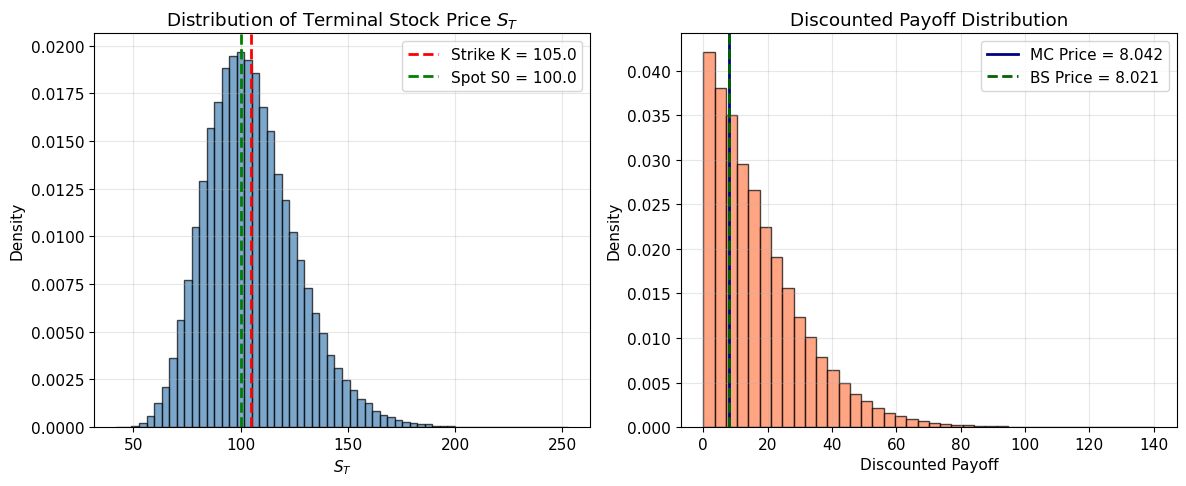

In [4]:
def european_call_mc(S0, K, T, r, sigma, N, seed=None):
    if seed is not None:
        np.random.seed(seed)
    Z = np.random.standard_normal(N)
    ST = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)
    payoff = np.maximum(ST - K, 0)
    price = np.exp(-r * T) * np.mean(payoff)
    stderr = np.exp(-r * T) * np.std(payoff, ddof=1) / np.sqrt(N)
    return price, stderr, ST, payoff

def bs_call(S0, K, T, r, sigma):
    d1 = (log(S0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * sqrt(T))
    d2 = d1 - sigma * sqrt(T)
    Nd1 = 0.5 * (1 + erf(d1 / sqrt(2)))
    Nd2 = 0.5 * (1 + erf(d2 / sqrt(2)))
    return S0 * Nd1 - K * exp(-r * T) * Nd2

# Parameters
S0, K, T, r, sigma = 100.0, 105.0, 1.0, 0.05, 0.2
N = 100000

price, stderr, ST, payoff = european_call_mc(S0, K, T, r, sigma, N, seed=42)
bs_price = bs_call(S0, K, T, r, sigma)

print("European Call Option Pricing")
print("-" * 40)
print("Monte Carlo price:   {:.4f} ± {:.4f}".format(price, 1.96 * stderr))
print("Black-Scholes price: {:.4f}".format(bs_price))
print("Relative error:      {:.4%}".format(abs(price - bs_price) / bs_price))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(ST, bins=60, density=True, alpha=0.7, color='steelblue', edgecolor='black')
axes[0].axvline(K, color='red', linestyle='--', lw=2, label='Strike K = {}'.format(K))
axes[0].axvline(S0, color='green', linestyle='--', lw=2, label='Spot S0 = {}'.format(S0))
axes[0].set_title('Distribution of Terminal Stock Price $S_T$')
axes[0].set_xlabel('$S_T$')
axes[0].set_ylabel('Density')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

discounted = np.exp(-r * T) * payoff
axes[1].hist(discounted[discounted > 0], bins=40, density=True, alpha=0.7, color='coral', edgecolor='black')
axes[1].axvline(price, color='navy', lw=2, label='MC Price = {:.3f}'.format(price))
axes[1].axvline(bs_price, color='darkgreen', lw=2, linestyle='--', label='BS Price = {:.3f}'.format(bs_price))
axes[1].set_title('Discounted Payoff Distribution')
axes[1].set_xlabel('Discounted Payoff')
axes[1].set_ylabel('Density')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 4. Variance Reduction: Antithetic Variates

A simple yet powerful variance reduction technique. For each uniform $U$, we also use $1-U$; for each normal $Z$, we use $-Z$.

The antithetic estimator:
$$\hat{I}_{\text{anti}} = \frac{1}{N} \sum_{i=1}^{N/2} \frac{f(X_i) + f(X_i')}{2}$$

If $f(X)$ and $f(X')$ are negatively correlated, the variance of the average is reduced. For monotonic functions and symmetric distributions, this often yields significant gains.


Variance Reduction for 1D Integration of exp(x)
Standard MC variance:     1.232033e-04
Antithetic MC variance:   3.949012e-06
Variance reduction ratio: 31.20x

Variance Reduction for European Call Option
Standard MC stderr:     0.1323
Antithetic MC stderr:   0.1045
Efficiency gain:        1.60x


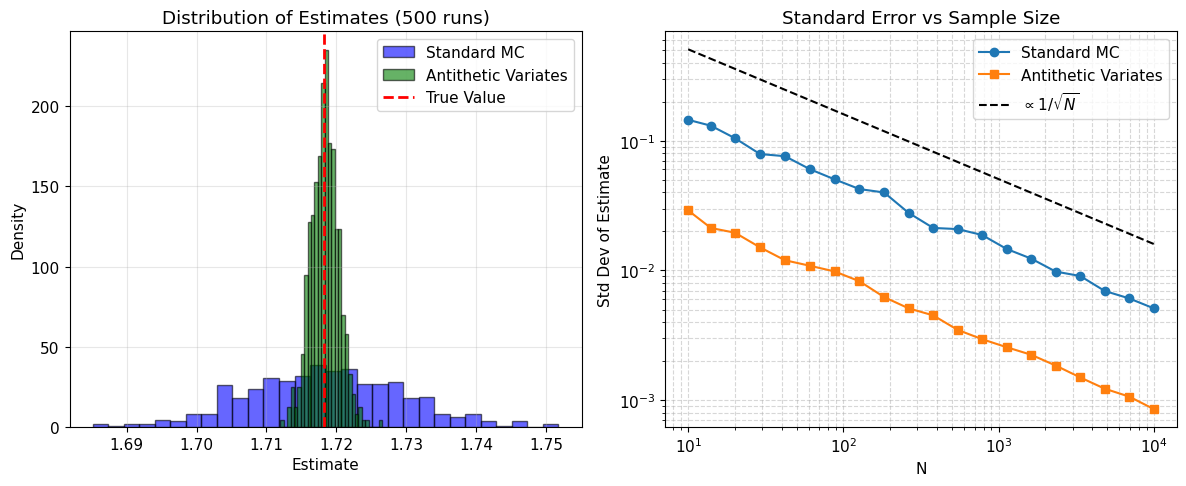

In [5]:
def mc_integral_antithetic(f, a, b, N):
    N = N // 2
    u = np.random.uniform(0, 1, N)
    x1 = a + u * (b - a)
    x2 = a + (1 - u) * (b - a)
    y1 = f(x1)
    y2 = f(x2)
    estimates = 0.5 * (y1 + y2)
    return (b - a) * np.mean(estimates), estimates

def option_antithetic(S0, K, T, r, sigma, N):
    N = N // 2
    Z = np.random.standard_normal(N)
    ST1 = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)
    ST2 = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * (-Z))
    p1 = np.maximum(ST1 - K, 0)
    p2 = np.maximum(ST2 - K, 0)
    avg_payoff = 0.5 * (p1 + p2)
    price = np.exp(-r * T) * np.mean(avg_payoff)
    stderr = np.exp(-r * T) * np.std(avg_payoff, ddof=1) / np.sqrt(N)
    return price, stderr

# Integration comparison
N_test = 2000
n_runs = 500
std_estimates = []
anti_estimates = []
for _ in range(n_runs):
    s, _ = mc_integral_1d(f1d, 0, 1, N_test)
    a, _ = mc_integral_antithetic(f1d, 0, 1, N_test)
    std_estimates.append(s)
    anti_estimates.append(a)

var_std = np.var(std_estimates, ddof=1)
var_anti = np.var(anti_estimates, ddof=1)

print("Variance Reduction for 1D Integration of exp(x)")
print("Standard MC variance:     {:.6e}".format(var_std))
print("Antithetic MC variance:   {:.6e}".format(var_anti))
print("Variance reduction ratio: {:.2f}x".format(var_std / var_anti))

# Option pricing comparison
opt_std, se_std, _, _ = european_call_mc(S0, K, T, r, sigma, 10000, seed=123)
opt_anti, se_anti = option_antithetic(S0, K, T, r, sigma, 10000)

print("\nVariance Reduction for European Call Option")
print("Standard MC stderr:     {:.4f}".format(se_std))
print("Antithetic MC stderr:   {:.4f}".format(se_anti))
print("Efficiency gain:        {:.2f}x".format((se_std / se_anti)**2))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(std_estimates, bins=30, density=True, alpha=0.6, color='blue', edgecolor='black', label='Standard MC')
axes[0].hist(anti_estimates, bins=30, density=True, alpha=0.6, color='green', edgecolor='black', label='Antithetic Variates')
axes[0].axvline(true_val_1d, color='red', lw=2, linestyle='--', label='True Value')
axes[0].set_title('Distribution of Estimates ({} runs)'.format(n_runs))
axes[0].set_xlabel('Estimate')
axes[0].set_ylabel('Density')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Convergence paths
N_path = np.logspace(1, 4, 20, dtype=int)
err_std_path = []
err_anti_path = []
for n in N_path:
    vals_s = []
    vals_a = []
    for _ in range(100):
        vals_s.append(mc_integral_1d(f1d, 0, 1, n)[0])
        vals_a.append(mc_integral_antithetic(f1d, 0, 1, n)[0])
    err_std_path.append(np.std(vals_s))
    err_anti_path.append(np.std(vals_a))

axes[1].loglog(N_path, err_std_path, 'o-', label='Standard MC')
axes[1].loglog(N_path, err_anti_path, 's-', label='Antithetic Variates')
axes[1].loglog(N_path, 1.6 / np.sqrt(N_path), 'k--', label=r'$\propto 1 / \sqrt{N}$')
axes[1].set_title('Standard Error vs Sample Size')
axes[1].set_xlabel('N')
axes[1].set_ylabel('Std Dev of Estimate')
axes[1].legend()
axes[1].grid(True, which='both', ls='--', alpha=0.5)

plt.tight_layout()
plt.show()


## 5. Convergence Rate and Error Analysis

Monte Carlo estimators converge at rate $O(N^{-1/2})$, regardless of dimension. This is slower than the trapezoidal rule ($O(N^{-2})$) in 1D, but MC does not suffer from the **curse of dimensionality**.

We verify this empirically by plotting the standard error versus $N$ on log-log axes. The slope should approach $-0.5$.


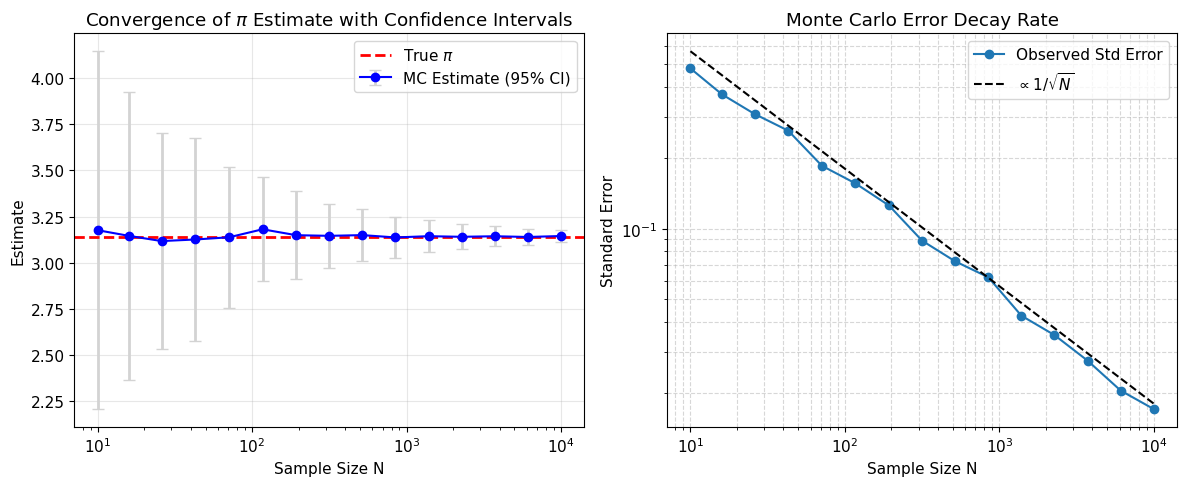

Observed convergence rate (log-log slope): -0.488
Theoretical expected slope: -0.500


In [6]:
def run_convergence_experiment(estimator_func, N_list, n_trials=200):
    stds = []
    for N in N_list:
        estimates = [estimator_func(N) for _ in range(n_trials)]
        stds.append(np.std(estimates, ddof=1))
    return np.array(stds)

def pi_estimator(N):
    x, y = np.random.rand(N), np.random.rand(N)
    return 4.0 * np.sum(x**2 + y**2 <= 1.0) / N

N_list = np.logspace(1, 4, 15, dtype=int)
std_pi = run_convergence_experiment(pi_estimator, N_list, n_trials=200)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Mean estimate with error bars from one long run
means = []
errs = []
for N in N_list:
    ests = [pi_estimator(N) for _ in range(100)]
    means.append(np.mean(ests))
    errs.append(np.std(ests, ddof=1))

axes[0].errorbar(N_list, means, yerr=1.96 * np.array(errs), fmt='o-', capsize=4,
                 color='blue', ecolor='lightgray', elinewidth=2, label='MC Estimate (95% CI)')
axes[0].axhline(np.pi, color='red', linestyle='--', lw=2, label='True $\\pi$')
axes[0].set_xscale('log')
axes[0].set_title('Convergence of $\\pi$ Estimate with Confidence Intervals')
axes[0].set_xlabel('Sample Size N')
axes[0].set_ylabel('Estimate')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Log-log error decay
axes[1].loglog(N_list, std_pi, 'o-', label='Observed Std Error')
axes[1].loglog(N_list, 1.8 / np.sqrt(N_list), 'k--', label=r'$\propto 1 / \sqrt{N}$')
axes[1].set_title('Monte Carlo Error Decay Rate')
axes[1].set_xlabel('Sample Size N')
axes[1].set_ylabel('Standard Error')
axes[1].legend()
axes[1].grid(True, which='both', ls='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Fit slope in log-log space
logN = np.log(N_list).astype(float)
logErr = np.log(std_pi)
slope = np.polyfit(logN, logErr, 1)[0]
print("Observed convergence rate (log-log slope): {:.3f}".format(slope))
print("Theoretical expected slope: -0.500")


## Summary

| Aspect | Key Result |
|--------|------------|
| **Convergence** | $O(N^{-1/2})$ independent of dimension |
| **Pi estimation** | Geometric sampling of unit square |
| **Integration** | Sample average scaled by domain volume |
| **Option pricing** | Risk-neutral expectation via GBM simulation |
| **Variance reduction** | Antithetic variates can significantly lower variance |

Monte Carlo is indispensable for high-dimensional integrals and problems lacking closed-form solutions, forming the backbone of modern computational finance and physics.
